In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [32]:
vgsales = pd.read_csv('vgsales.csv')

vgsales = vgsales.dropna(subset=['Year'])
vgsales['Year'] = vgsales['Year'].astype(int) 

vgsales.head(10).reset_index(drop=True)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


In [33]:
print('- DUOMENŲ DYDIS -')
print(vgsales.shape)
print()
print('- INFORMACIJA APIE STULPELIUS -')
print(vgsales.dtypes)
print()
print('- PAGRINDINĖ STATISTIKA -')
print(vgsales.describe())

- DUOMENŲ DYDIS -
(16327, 11)

- INFORMACIJA APIE STULPELIUS -
Rank              int64
Name                str
Platform            str
Year              int64
Genre               str
Publisher           str
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

- PAGRINDINĖ STATISTIKA -
               Rank          Year      NA_Sales      EU_Sales      JP_Sales  \
count  16327.000000  16327.000000  16327.000000  16327.000000  16327.000000   
mean    8292.868194   2006.406443      0.265415      0.147554      0.078661   
std     4792.669778      5.828981      0.821591      0.508766      0.311557   
min        1.000000   1980.000000      0.000000      0.000000      0.000000   
25%     4136.500000   2003.000000      0.000000      0.000000      0.000000   
50%     8295.000000   2007.000000      0.080000      0.020000      0.000000   
75%    12441.500000   2010.000000      0.240000      0.110000      0.040000   


### Hipotezė 1
Veiksmo žanro žaidimų vidutiniai pasauliniai pardavimai yra didesni nei kitų žanrų žaidimų.

In [34]:
pardavimai_pagala_zanra = vgsales.groupby('Genre')['Global_Sales'].mean().sort_values(ascending=False)
pardavimai_pagala_zanra.reset_index() 

,Genre,Global_Sales
0,Platform,0.946518
1,Shooter,0.800468
2,Role-Playing,0.628035
3,Racing,0.592798
4,Sports,0.568247
5,Fighting,0.531160
6,Action,0.529628
7,Misc,0.466444
8,Simulation,0.458472
9,Puzzle,0.424203


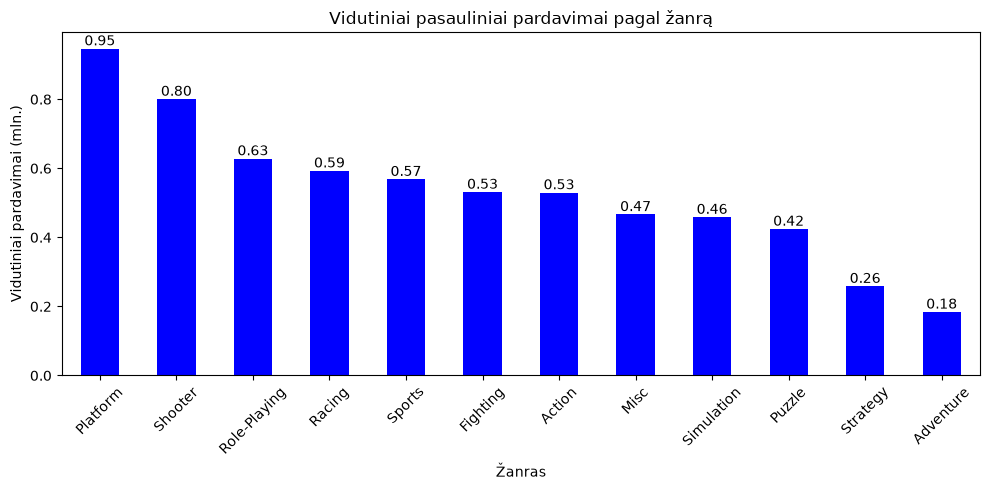

In [35]:
plt.figure(figsize=(10,5))
ax = pardavimai_pagala_zanra.plot(kind='bar', color='blue')
plt.title('Vidutiniai pasauliniai pardavimai pagal žanrą')
plt.xlabel('Žanras')
plt.ylabel('Vidutiniai pardavimai (mln.)')
plt.xticks(rotation=45)
ax.bar_label(ax.containers[0], fmt='%.2f')
plt.tight_layout()
plt.show()

### Hipotezė 2
Nintendo platformų žaidimų vidutiniai pasauliniai pardavimai yra didesni nei PlayStation platformų žaidimų.

Nintendo vidurkis: 0.566
PlayStation vidurkis: 0.539


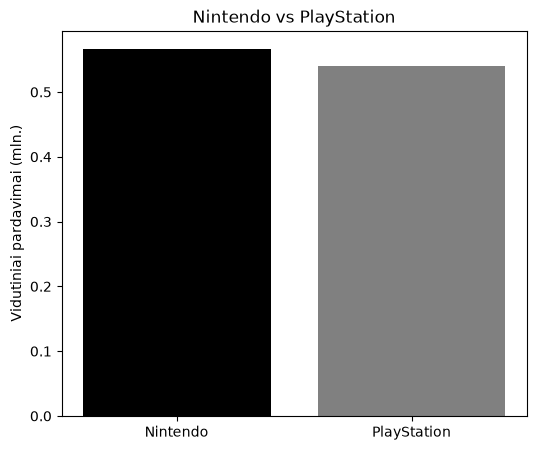

In [36]:
nintendo = ['NES', 'SNES', 'N64', 'GC', 'Wii', 'WiiU', 'GB', 'GBA', 'DS', '3DS', 'Switch']

playstation = ['PS', 'PS2', 'PS3', 'PS4', 'PSP', 'PSV']


nintendo_sales = vgsales[vgsales['Platform'].isin(nintendo)]['Global_Sales']
playstation_sales = vgsales[vgsales['Platform'].isin(playstation)]['Global_Sales']


print('Nintendo vidurkis:', nintendo_sales.mean().round(3))
print('PlayStation vidurkis:', playstation_sales.mean().round(3))


plt.figure(figsize=(6, 5))
plt.bar(['Nintendo', 'PlayStation'], [nintendo_sales.mean(), playstation_sales.mean()],color=['black', 'grey'])
plt.ylabel('Vidutiniai pardavimai (mln.)')
plt.title('Nintendo vs PlayStation')
plt.show()

### Hipotezė 3
Po 2000 metų buvo išleidžiama daugiau vaizdo žaidimų nei iki 2000 metų.

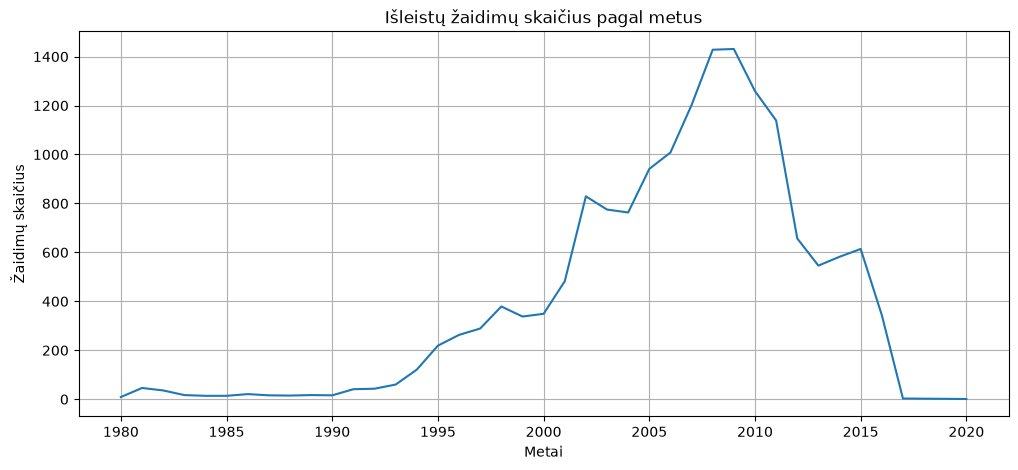

In [37]:
zaidimai_per_metus = vgsales.groupby('Year').size()

plt.figure(figsize=(12,5))
zaidimai_per_metus.plot()

plt.title('Išleistų žaidimų skaičius pagal metus')
plt.xlabel('Metai')
plt.ylabel('Žaidimų skaičius')
plt.grid(True)
plt.show()

In [38]:
periodai = {
    "Iki 2000": vgsales[vgsales['Year'] < 2000].shape[0],
    "2000-2010": vgsales[(vgsales['Year'] >= 2000) & (vgsales['Year'] <= 2010)].shape[0],
    "2011-2020": vgsales[(vgsales['Year'] > 2010) & (vgsales['Year'] <= 2020)].shape[0]
}

periodu_lentele = pd.DataFrame(
    list(periodai.items()),
    columns=['Laikotarpis', 'Žaidimų skaičius']
)

periodu_lentele.reset_index(drop=True)

,Laikotarpis,Žaidimų skaičius
0,Iki 2000,1974
1,2000-2010,10467
2,2011-2020,3886


### Machine Learning
Linear Regression modelis

In [39]:
duomenys = vgsales[
    ['Year', 'Platform', 'Genre', 'Publisher', 'Global_Sales']
].dropna()

X = duomenys[['Year', 'Platform', 'Genre', 'Publisher']]
y = duomenys['Global_Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            'kategoriniai',
            OneHotEncoder(handle_unknown='ignore'),
            ['Platform', 'Genre', 'Publisher']
        )
    ],
    remainder='passthrough'
)

modelis = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

modelis.fit(X_train, y_train)

prognozes = modelis.predict(X_test)

mae = mean_absolute_error(y_test, prognozes)
rmse = mean_squared_error(y_test, prognozes) ** 0.5
r2 = r2_score(y_test, prognozes)

print('MAE:', round(mae, 3))
print('RMSE:', round(rmse, 3))
print('R²:', round(r2, 3))

MAE: 0.562
RMSE: 1.976
R²: 0.087


### Bendri Šiaurės Amerikos ir Europos pardavimai.

NA: 4333.43
EU: 2409.12


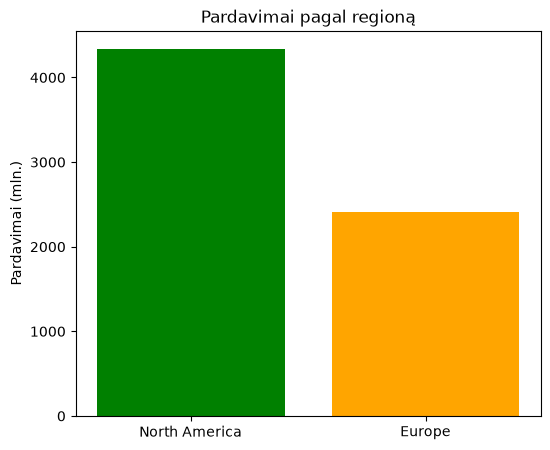

In [40]:
na = vgsales['NA_Sales'].sum()
eu = vgsales['EU_Sales'].sum()

print('NA:', round(na, 3))
print('EU:', round(eu, 3))

plt.figure(figsize=(6,5))
plt.bar(['North America', 'Europe'], [na, eu], color=['green', 'orange'])

plt.ylabel('Pardavimai (mln.)')
plt.title('Pardavimai pagal regioną')
plt.show()

### Ppildoma analizė: Šiaurės Amerikos ir pasaulinių pardavimų ryšys

Koreliacija: 0.941


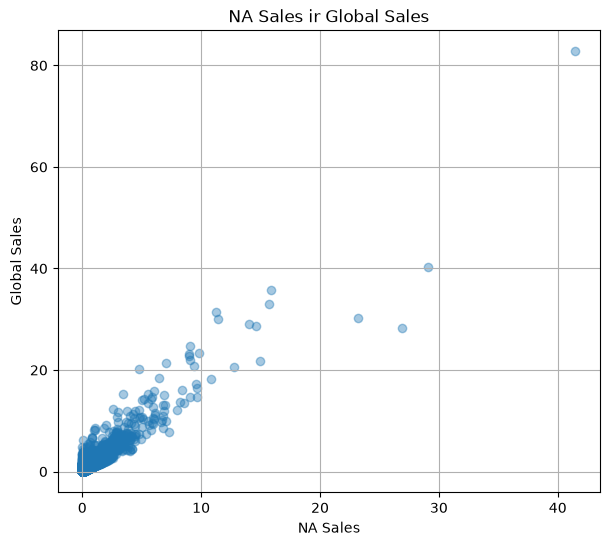

In [41]:
Koreliacija = vgsales['NA_Sales'].corr(vgsales['Global_Sales'])

print('Koreliacija:', round(Koreliacija, 3))

plt.figure(figsize=(7, 6))
plt.scatter(vgsales['NA_Sales'], vgsales['Global_Sales'], alpha=0.4)
plt.xlabel('NA Sales')
plt.ylabel('Global Sales')
plt.title('NA Sales ir Global Sales')
plt.grid(True)
plt.show()

In [43]:
print(vgsales[['Name', 'Platform', 'Year', 'Genre', 'Global_Sales']].sort_values('Global_Sales', ascending=False).head(17))

                           Name Platform  Year         Genre  Global_Sales
0                    Wii Sports      Wii  2006        Sports         82.74
1             Super Mario Bros.      NES  1985      Platform         40.24
2                Mario Kart Wii      Wii  2008        Racing         35.82
3             Wii Sports Resort      Wii  2009        Sports         33.00
4      Pokemon Red/Pokemon Blue       GB  1996  Role-Playing         31.37
5                        Tetris       GB  1989        Puzzle         30.26
6         New Super Mario Bros.       DS  2006      Platform         30.01
7                      Wii Play      Wii  2006          Misc         29.02
8     New Super Mario Bros. Wii      Wii  2009      Platform         28.62
9                     Duck Hunt      NES  1984       Shooter         28.31
10                   Nintendogs       DS  2005    Simulation         24.76
11                Mario Kart DS       DS  2005        Racing         23.42
12  Pokemon Gold/Pokemon 